In [4]:
import requests
import lxml
from bs4 import BeautifulSoup
import pandas as pd
import time

## 1. BeautifulSoup 으로 시도
- 베스트 도전은 정적으로 보이지만 실시간으로 순위가 바뀌는 동적 페이지
- 동적페이지이므로 BeautifulSoup으로는 크롤링이 불가능

In [6]:
# 1. 데이터를 담을 리스트와 시작 페이지 설정
all_quotes = []
page = 1

# 헤더 설정 (내 브라우저 정보 흉내내기)
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
}

print("크롤링을 시작합니다...\n")

while True:
    # URL 설정
    url = f'https://comic.naver.com/bestChallenge?page={page}'
    response = requests.get(url)
    
    # 연결 확인
    if response.status_code != 200:
        print(f"{page}페이지를 불러오지 못했습니다.")
        break
        
    soup = BeautifulSoup(response.text, 'lxml')
    quotes = soup.select('.ChallengeListItem__info_area--hnJTz')
    
    # 만약 수집된 리스트가 비어있다면 반복문 탈출
    if not quotes:
        print(f"\n{page}페이지에 데이터가 없습니다. 크롤링을 종료합니다.")
        break    
    # 데이터 추출
    for q in quotes:
        # 제목 추출
        title = q.select_one('.ContentTitle__title--e3qXt').text
        
        # 작가 추출
        author = q.select_one('.ContentAuthor__author--CTAAP').text
        
        # 별점 추출
        # .Rating__star_area--dFzsb 클래스 내부의 .text 클래스를 찾으면 됩니다.
        rating = q.select_one('.Rating__star_area--dFzsb .text').text
        
        # 조회수 추출
        # .Rating__view_area--GQb_S 클래스 내부의 .text 클래스를 찾으면 됩니다.
        views = q.select_one('.Rating__view_area--GQb_S .text').text

        '''
        # BeautifulSoup 에서 구조적 접근 방식
        # q는 웹툰 카드 하나(예: <li> 태그)라고 가정합니다.
        # .select_one('태그[속성^="시작문자열"]') 문법 활용        
        title  = q.select_one('strong[class^="ContentTitle__title"]').text
        author = q.select_one('a[class^="ContentAuthor__author"]').text
        # 별점과 조회수는 'Rating'으로 시작하는 영역 안의 텍스트(span 등)를 순서대로 가져옴
        rating = q.select_one('[class^="Rating__star_area"] .text').text
        views  = q.select_one('[class^="Rating__view_area"] .text').text
        '''
        
        all_quotes.append({
            'Title': title,
            'Author': author,
            'Rating': rating,
            'Views': views,
        })
        
    print(f"현재 {page}페이지 완료 (수집된 내용: {len(all_quotes)}개)")

    time.sleep(0.5)

    # 작업이 끝난 후 무조건 페이지 번호 증가
    page += 1
    
    # 다음 페이지가 있는지 확인 (Next 버튼 여부 조사)
    # next_button = soup.select_one('li.next') # li 태그의 next 클래스
    
    # if next_button:
    #     page += 1  # 다음 페이지로 번호 증가
    # else:
    #     print("\n마지막 페이지에 도달했습니다. 종료합니다.")
    #     break

# 2. 데이터프레임 생성 및 확인
df = pd.DataFrame(all_quotes)

# 주피터 노트북에서 표 형태로 바로 확인
display(df.head())

# CSV 저장 (인덱스 제외)
# df.to_csv('Webtoon.csv', index=False, encoding='utf-8-sig')

크롤링을 시작합니다...


2페이지에 데이터가 없습니다. 크롤링을 종료합니다.


""


### 💡 CSS 속성 선택자 3대장

* **`^=` (시작 부분 일치): "~로 시작하면 합격!"**
    * **예시**: `[class^="Rating__star"]`
    * **의미**: 클래스 이름이 `Rating__star`로 **시작**하기만 하면, 뒤에 어떤 해시값이 붙든 상관없이 가져옵니다.
    * **팁**: `^`는 보통 '처음'을 뜻하는 기호라서 `=` 앞에 붙여서 "시작이 같다"는 뜻을 만듭니다.

* **`*=` (부분 일치): "어디든 포함만 되면 합격!"**
    * **예시**: `[class*="star_area"]`
    * **의미**: 클래스 이름 **중간** 어딘가에 `star_area`라는 글자만 들어있으면 다 가져옵니다. 가장 관대한 녀석이죠.

* **`$=` (끝 부분 일치): "~로 끝나면 합격!"**
    * **예시**: `[class$="e3qXt"]`
    * **의미**: 클래스 이름이 특정 문자열로 **끝날 때** 사용합니다. 크롤링할 때는 해시값이 끝에 붙으므로 자주 쓰진 않지만, 파일 확장자(예: `.jpg`) 등을 찾을 때 아주 유용합니다.

---

### 🚀 헷갈리지 않는 팁!

1.  **`^` (삿갓 모양)**: 화살표가 위를 향하죠? **"제일 위(처음)부터 본다"**고 생각하세요.
2.  **`*` (별표)**: 모든 것을 아우르는 별! **"어디에 있든 상관없다"**고 생각하세요.
3.  **`=` (는)**: 항상 뒤에 옵니다. `^=`, `*=`, `$=` 순서입니다.

In [8]:
# selenium 설치
# %pip install selenium webdriver-manager

  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 12.1 MB/s  0:00:00 eta 0:00:01
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: certifi
    Found existing installation: certifi 2025.11.12
    Uninstalling certifi-2025.11.12:
      Successfully uninstalled certifi-2025.11.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [selenium]7/8 [selenium]
Note: you may need to restart the kernel to use updated packages.


In [9]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time

## 2. selenium 으로 시도
- 베스트 도전은 정적으로 보이지만 실시간으로 순위가 바뀌는 동적 페이지
- 동적페이지이므로 selenium 으로 크롤링 가능

In [12]:
# 1. 브라우저 설정
chrome_options = Options()
# chrome_options.add_argument('--headless') # 창 없이 실행하고 싶을 때 주석 해제

service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

all_quotes = []
page = 1

print("🚀 네이버 웹툰 베스트 도전 전체 크롤링 시작!")

try:
    while True:
        url = f'https://comic.naver.com/bestChallenge?page={page}'
        driver.get(url)
        time.sleep(1.5)  # 로딩 대기시간 (네이버 서버 부하 방지)

        # 현재 페이지의 웹툰 리스트 가져오기
        quotes = driver.find_elements(By.CLASS_NAME, 'ChallengeListItem__info_area--hnJTz')

        # 데이터가 아예 없으면 (마지막 페이지를 넘겼을 때) 종료
        if not quotes:
            print(f"\n✅ {page}페이지에 데이터가 없습니다. 수집을 완료합니다.")
            break

        for q in quotes:
            try:
                title = q.find_element(By.CLASS_NAME, 'ContentTitle__title--e3qXt').text
                author = q.find_element(By.CLASS_NAME, 'ContentAuthor__author--CTAAP').text
                # 덩어리째 가져옴 → .replace() 필수 (노가다 발생) - 살짝 빠름
                # rating = q.find_element(By.CLASS_NAME, 'Rating__star_area--dFzsb').text.replace('별점', '').strip()
                # views = q.find_element(By.CLASS_NAME, 'Rating__view_area--GQb_S').text.replace('조회수', '').strip()
                
                # 특정 자식만 지정 → 추가 작업 불필요 (스마트함)
                rating = q.find_element(By.CSS_SELECTOR, '.Rating__star_area--dFzsb .text').text
                views = q.find_element(By.CSS_SELECTOR, '.Rating__view_area--GQb_S .text').text
                
                '''
                # selenium 에서 구조적 접근 방식
                # 1. 제목: strong 태그이면서 클래스명이 ContentTitle__title로 시작하는 요소
                title = q.find_element(By.CSS_SELECTOR, 'strong[class^="ContentTitle__title"]').text
                # 2. 작가: 클래스명이 ContentAuthor__author로 시작하는 요소
                author = q.find_element(By.CSS_SELECTOR, '[class^="ContentAuthor__author"]').text
                # 3. 별점: '별점'이라는 글자를 굳이 지울 필요 없이, 숫자가 들어있는 특정 자식 요소(.text)만 지목
                rating = q.find_element(By.CSS_SELECTOR, '[class^="Rating__star_area"] .text').text
                # 4. 조회수: 마찬가지로 숫자가 들어있는 자식 요소만 지목
                views = q.find_element(By.CSS_SELECTOR, '[class^="Rating__view_area"] .text').text
                '''
                all_quotes.append({
                    'Title': title,
                    'Author': author,
                    'Rating': rating,
                    'Views': views,
                })
            except:
                continue
        
        print(f"📦 {page}페이지 완료 (누적 수집: {len(all_quotes)}개)")
        
        # --- [중요] 다음 페이지 버튼 존재 여부 확인 ---
        # 다음 버튼이 비활성화(disabled) 되어 있으면 루프 종료
        next_btn = driver.find_elements(By.CLASS_NAME, 'PageNavigation__button_next--B9N_1')
        if next_btn:
            # 버튼은 있는데 클릭 불가능한 상태(disabled)인지 체크
            is_disabled = next_btn[0].get_attribute("disabled")
            if is_disabled is not None: # disabled 속성이 있으면 끝!
                print("\n🏁 마지막 페이지에 도달했습니다!")
                break
        
        page += 1

except Exception as e:
    print(f"❌ 에러 발생: {e}")

finally:
    driver.quit()
    print(f"✨ 총 {len(all_quotes)}개의 데이터를 수집했습니다.")

# 2. 데이터 저장 및 확인
df = pd.DataFrame(all_quotes)
df.to_csv('Webtoon_All.csv', index=False, encoding='utf-8-sig')
display(df)

🚀 네이버 웹툰 베스트 도전 전체 크롤링 시작!
📦 1페이지 완료 (누적 수집: 30개)
📦 2페이지 완료 (누적 수집: 60개)
📦 3페이지 완료 (누적 수집: 90개)
📦 4페이지 완료 (누적 수집: 120개)
📦 5페이지 완료 (누적 수집: 150개)
📦 6페이지 완료 (누적 수집: 180개)
📦 7페이지 완료 (누적 수집: 210개)
📦 8페이지 완료 (누적 수집: 240개)
📦 9페이지 완료 (누적 수집: 270개)
📦 10페이지 완료 (누적 수집: 300개)
📦 11페이지 완료 (누적 수집: 330개)
📦 12페이지 완료 (누적 수집: 360개)
📦 13페이지 완료 (누적 수집: 390개)
📦 14페이지 완료 (누적 수집: 420개)
📦 15페이지 완료 (누적 수집: 450개)
📦 16페이지 완료 (누적 수집: 480개)
📦 17페이지 완료 (누적 수집: 510개)
📦 18페이지 완료 (누적 수집: 540개)
📦 19페이지 완료 (누적 수집: 570개)
📦 20페이지 완료 (누적 수집: 600개)
📦 21페이지 완료 (누적 수집: 630개)
📦 22페이지 완료 (누적 수집: 660개)
📦 23페이지 완료 (누적 수집: 690개)
📦 24페이지 완료 (누적 수집: 720개)
📦 25페이지 완료 (누적 수집: 750개)
📦 26페이지 완료 (누적 수집: 780개)
📦 27페이지 완료 (누적 수집: 810개)
📦 28페이지 완료 (누적 수집: 840개)
📦 29페이지 완료 (누적 수집: 870개)
📦 30페이지 완료 (누적 수집: 900개)
📦 31페이지 완료 (누적 수집: 930개)
📦 32페이지 완료 (누적 수집: 960개)
📦 33페이지 완료 (누적 수집: 990개)
📦 34페이지 완료 (누적 수집: 1020개)
📦 35페이지 완료 (누적 수집: 1050개)
📦 36페이지 완료 (누적 수집: 1080개)
📦 37페이지 완료 (누적 수집: 1110개)
📦 38페이지 완료 (누적 수집: 1140개)
📦 39페이지 완료 (누적 수집: 1170개)
📦 40

,Title,Author,Rating,Views
0,N년째 외사랑,As,9.29,38만
1,네게선 레몬향이 났다,유쟈,9.19,19만
2,검은 늑대,MOCA,9.87,81만
3,카나와 초나의 독일,카나,9.85,722만
4,도원향,Lee Hajin,9.87,95만
...,...,...,...,...
4630,반쪽짜리 이야기,hwip****,8.09,"5,777"
4631,야도닷껌,na****,4.59,2.7만
4632,포토쥬스,txen****,4.79,1.4만
4633,김모군의 일기,lesn****,7.14,4.6만


In [16]:
df['Author'].value_counts()

Author
blac****    11
stud****    10
blue****     8
drea****     7
re****       7
            ..
hwar****     1
무농이          1
wkwk****     1
김건호          1
uc****       1
Name: count, Length: 3596, dtype: int64

In [18]:
# 1. 'blac****' 작가의 작품만 필터링 (정확히 일치하는 경우)
target_author = 'blac****'
author_df = df[df['Author'] == target_author]

# 2. 결과 확인
print(f"'{target_author}' 작가의 작품 수: {len(author_df)}개")
display(author_df)

# 3. (옵션) 이 작가의 작품만 따로 CSV로 저장하고 싶다면?
# author_df.to_csv('Black_Author_Works.csv', index=False, encoding='utf-8-sig')

'blac****' 작가의 작품 수: 11개


,Title,Author,Rating,Views
1850,뼈의 시간,blac****,9.76,49만
1893,두꺼비집,blac****,9.72,44만
2630,언메이크,blac****,9.26,21만
2769,저도 편집자는 처음이라,blac****,9.62,5.5만
3080,개천사,blac****,9.89,141만
3249,돌아와 리즈!,blac****,9.77,78만
3529,체크포인트,blac****,9.58,43만
3538,리얼 소꿉친구,blac****,9.86,274만
3594,옥수수군의 일기,blac****,9.81,30만
3648,내 학생이 싸이코패스일 리가 없어,blac****,9.85,326만


In [22]:
def convert_view(v):
    # 1. 쉼표(,) 제거
    v = v.replace(',', '')
    
    # 2. '만' 단위 처리
    if '만' in v:
        return float(v.replace('만', '')) * 10000
    
    # 3. 단위가 없는 경우 (예: '5747') 바로 숫자로 변환
    try:
        return float(v)
    except ValueError:
        return 0.0 # 변환 실패 시 0 처리

# 데이터 적용
df['Views_Num'] = df['Views'].apply(convert_view)
df['Rating_Num'] = pd.to_numeric(df['Rating'], errors='coerce') # 에러 발생 시 NaN 처리

print("✅ 변환 완료!")
display(df[['Title', 'Views', 'Views_Num']].head())

✅ 변환 완료!


,Title,Views,Views_Num
0,N년째 외사랑,38만,380000.0
1,네게선 레몬향이 났다,19만,190000.0
2,검은 늑대,81만,810000.0
3,카나와 초나의 독일,722만,7220000.0
4,도원향,95만,950000.0


In [26]:
# 한글 표시를 위해 koreanize-matplotlib 설치
# %pip install koreanize-matplotlib

  Using cached koreanize_matplotlib-0.1.1-py3-none-any.whl.metadata (992 bytes)
Using cached koreanize_matplotlib-0.1.1-py3-none-any.whl (7.9 MB)
Note: you may need to restart the kernel to use updated packages.


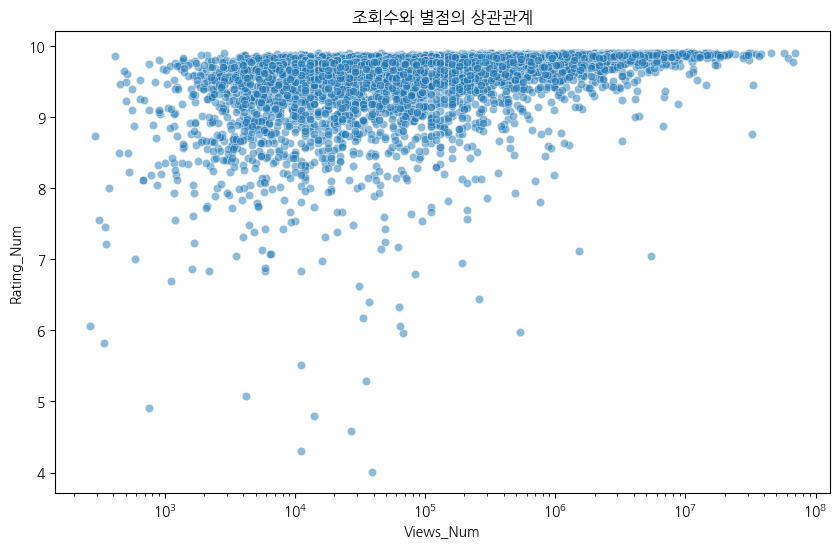

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 한글 깨짐 방지 설정 (Windows 기준)
# plt.rc('font', family='Malgun Gothic')

# 조회수 텍스트(예: 10만, 5000만)를 숫자로 변환하는 함수가 필요하겠네요!
# def convert_view(v):
#     if '만' in v:
#         return float(v.replace('만', '')) * 10000
#     elif '억' in v:
#         return float(v.replace('억', '')) * 100000000
#     return float(v)

# df['Views_Num'] = df['Views'].apply(convert_view)
# df['Rating_Num'] = pd.to_numeric(df['Rating'])

# 시각화: 조회수와 별점의 상관관계 (산점도)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Views_Num', y='Rating_Num', alpha=0.5)
plt.title('조회수와 별점의 상관관계')
plt.xscale('log') # 조회수 편차가 크므로 로그 스케일 추천!
plt.show()

In [37]:
# 컬럼명을 대문자로 수정 (Title, Author)
duplicates = df[df.duplicated(subset=['Title', 'Author'], keep=False)]

# 중복된 데이터 출력
if len(duplicates) > 0:
    print(f"총 {len(duplicates)}개의 중복 항목을 발견했습니다.")
    display(duplicates.sort_values(by='Title')) # 보기 좋게 정렬
else:
    print("중복된 데이터가 없습니다.")

총 16개의 중복 항목을 발견했습니다.


,Title,Author,Rating,Views,Views_Num,Rating_Num
230,14년 만에 핀 해바라기,단심,8.08,"5,846",5846.0,8.08
2968,14년 만에 핀 해바라기,단심,9.71,41만,410000.0,9.71
887,기억의 해석,김유채,9.04,9.8만,98000.0,9.04
1771,기억의 해석,김유채,8.04,4.5만,45000.0,8.04
1465,도깨비신선,이갱,8.78,1.2만,12000.0,8.78
1466,도깨비신선,이갱,9.30,5.9만,59000.0,9.30
1136,라스가에!,nota****,9.35,12만,120000.0,9.35
1137,라스가에!,nota****,9.65,39만,390000.0,9.65
1183,로판도 식후경,king****,9.76,7.3만,73000.0,9.76
1437,로판도 식후경,king****,9.88,46만,460000.0,9.88


### 1. 중복 데이터간의 차이 확인

In [38]:
# 중복된 그룹별로 조회수 최대값과 최소값의 차이 계산
diff_check = duplicates.groupby(['Title', 'Author'])['Views_Num'].agg(['max', 'min'])
diff_check['diff'] = diff_check['max'] - diff_check['min']
display(diff_check.sort_values(by='diff', ascending=False).head(10))

,,max,min,diff
Title,Author,,,
요괴백정,JoA,4870000.0,310000.0,4560000.0
14년 만에 핀 해바라기,단심,410000.0,5846.0,404154.0
로판도 식후경,king****,460000.0,73000.0,387000.0
라스가에!,nota****,390000.0,120000.0,270000.0
안단테,ran5****,580000.0,370000.0,210000.0
일니스,빵봉지,98000.0,2922.0,95078.0
기억의 해석,김유채,98000.0,45000.0,53000.0
도깨비신선,이갱,59000.0,12000.0,47000.0


### 2. 조회수가 가장 높은 것만 남기기

In [40]:
# 1. 먼저 조회수(Views_Num) 기준으로 내림차순 정렬
df_sorted = df.sort_values(by=['Title', 'Author', 'Views_Num'], ascending=[True, True, False])

# 2. 중복 제거 시 '첫 번째'(즉, 조회수가 가장 높은 것)만 남김
df_final = df_sorted.drop_duplicates(subset=['Title', 'Author'], keep='first')

print(f"정리 전: {len(df)}개 -> 정리 후: {len(df_final)}개")

정리 전: 4635개 -> 정리 후: 4627개
